# DSAI 490 - Assignment 1: Representation Learning with Autoencoders (AE & VAE)

**Dataset:** Medical MNIST (6 classes: AbdomenCT, BreastMRI, CXR, ChestCT, Hand, HeadCT)

**Goal:** Train a vanilla convolutional Autoencoder (AE) and a convolutional Variational Autoencoder (VAE) on medical images, then compare reconstruction quality, latent-space structure, sample generation and denoising behaviour.

**Code convention:** Keras functional API (matches Lab 3: `keras.Input`, `layers.Conv2D`, `layers.Conv2DTranspose`, `keras.Model(inputs, outputs)`), `tf.data` pipelines, Adam + binary-crossentropy reconstruction loss.

## 1. Imports and configuration

In [18]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

# ---- Reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ---- Paths (auto-detect Medical MNIST location on Kaggle) ----
CANDIDATE_ROOTS = [
    '/kaggle/input/medical-mnist',
    '/kaggle/input/datasets/andrewmvd/medical-mnist',
]
DATA_ROOT = None
for c in CANDIDATE_ROOTS:
    if os.path.isdir(c) and any(os.path.isdir(os.path.join(c, d)) for d in os.listdir(c)):
        DATA_ROOT = c; break
# Fallback: search one level deep under /kaggle/input
if DATA_ROOT is None:
    for root in glob.glob('/kaggle/input/*'):
        if os.path.isdir(os.path.join(root, 'AbdomenCT')):
            DATA_ROOT = root; break
        for sub in glob.glob(os.path.join(root, '*')):
            if os.path.isdir(os.path.join(sub, 'AbdomenCT')):
                DATA_ROOT = sub; break
        if DATA_ROOT: break
assert DATA_ROOT is not None, 'Medical MNIST dataset not found under /kaggle/input/. Attach the dataset to the notebook.'
print('DATA_ROOT =', DATA_ROOT)

OUT_DIR = '/kaggle/working'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
MODEL_DIR = os.path.join(OUT_DIR, 'models')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ---- Hyperparameters ----
IMG_SIZE = 64          # Medical MNIST is natively 64x64
BATCH_SIZE = 128
EPOCHS = 30            # kept modest; dataset is easy, more epochs overfit reconstruction
LATENT_DIM = 16        # VAE latent dimensionality
AE_BOTTLENECK_CHANNELS = 16  # AE bottleneck is spatial (8x8x8 = 512 dims) -- intentionally larger than VAE

print('TF:', tf.__version__, '| Keras:', keras.__version__)

DATA_ROOT = /kaggle/input/datasets/andrewmvd/medical-mnist
TF: 2.19.0 | Keras: 3.10.0


## 2. Data pipeline with `tf.data`

The dataset is laid out as `<DATA_ROOT>/<ClassName>/*.jpeg`. We build a single flat list of paths, split into train/val/test, and wrap in `tf.data.Dataset`. Labels are kept only for latent-space visualisation; the AE/VAE themselves are unsupervised.

In [19]:
CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT)
                      if os.path.isdir(os.path.join(DATA_ROOT, d))])
print('Classes:', CLASS_NAMES)

all_paths, all_labels = [], []
for idx, cls in enumerate(CLASS_NAMES):
    paths = glob.glob(os.path.join(DATA_ROOT, cls, '*'))
    all_paths.extend(paths)
    all_labels.extend([idx] * len(paths))
all_paths = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)
print(f'Total images: {len(all_paths)}')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:12s}: {(all_labels == idx).sum()}')

# Shuffle deterministically, then split 80/10/10
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(all_paths))
all_paths, all_labels = all_paths[perm], all_labels[perm]

n = len(all_paths)
n_train = int(0.8 * n); n_val = int(0.1 * n)
train_p, val_p, test_p = all_paths[:n_train], all_paths[n_train:n_train+n_val], all_paths[n_train+n_val:]
train_l, val_l, test_l = all_labels[:n_train], all_labels[n_train:n_train+n_val], all_labels[n_train+n_val:]
print(f'Split -> train: {len(train_p)}, val: {len(val_p)}, test: {len(test_p)}')

Classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Total images: 58954
  AbdomenCT   : 10000
  BreastMRI   : 8954
  CXR         : 10000
  ChestCT     : 10000
  Hand        : 10000
  HeadCT      : 10000
Split -> train: 47163, val: 5895, test: 5896


In [20]:
def _decode_image(path):
    """Load a grayscale image, resize to IMG_SIZE x IMG_SIZE, scale to [0,1]."""
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_ds(paths, labels, training=False, with_labels=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(paths), 4096), seed=SEED)
    if with_labels:
        ds = ds.map(lambda p, y: (_decode_image(p), y), num_parallel_calls=tf.data.AUTOTUNE)
    else:
        # AE/VAE: target == input
        ds = ds.map(lambda p, y: (_decode_image(p), _decode_image(p)), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_p, train_l, training=True)
val_ds   = make_ds(val_p,   val_l)
test_ds  = make_ds(test_p,  test_l)

# Labelled versions for latent-space plots
test_ds_labelled = make_ds(test_p, test_l, with_labels=True)

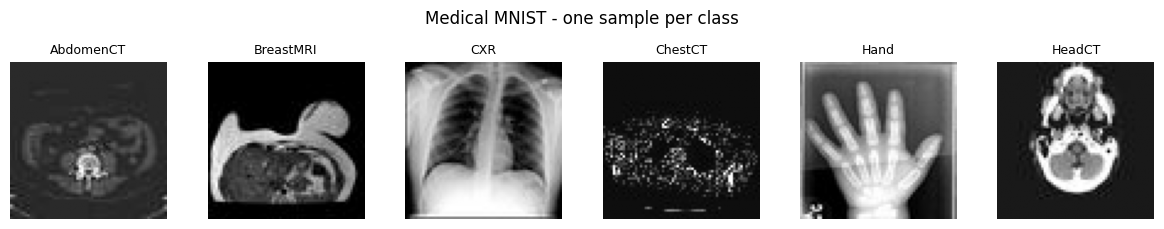

In [21]:
# Sanity-check: plot one image per class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(2*len(CLASS_NAMES), 2.2))
for i, cls in enumerate(CLASS_NAMES):
    p = glob.glob(os.path.join(DATA_ROOT, cls, '*'))[0]
    img = _decode_image(p).numpy().squeeze()
    axes[i].imshow(img, cmap='gray'); axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Medical MNIST - one sample per class', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_dataset_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Vanilla Autoencoder (AE)

Same style as Lab 3: stacked `Conv2D + MaxPooling2D` for the encoder, `Conv2DTranspose` for the decoder, `binary_crossentropy` reconstruction loss.

Input 64x64x1 -> encoder -> 8x8x8 latent feature map -> decoder -> 64x64x1.

In [22]:
def build_ae():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)          # 32x32
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)          # 16x16
    x = layers.Conv2D(AE_BOTTLENECK_CHANNELS, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)    # 8x8x8

    # Decoder
    x = layers.Conv2DTranspose(16, (3, 3), strides=(2, 2), activation='relu', padding='same')(encoded)
    x = layers.Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    ae = keras.Model(inp, decoded, name='autoencoder')
    encoder = keras.Model(inp, encoded, name='ae_encoder')
    return ae, encoder

ae, ae_encoder = build_ae()
ae.compile(optimizer='adam', loss='binary_crossentropy')
ae.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 16, 16, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 32, 32, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 64, 64, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,761 (92.82 KB)

 Trainable params: 23,761 (92.82 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
ae_history = ae.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
ae.save(os.path.join(MODEL_DIR, 'ae.keras'))

Epoch 1/30
369/369 - 28s - 77ms/step - loss: 0.5000 - val_loss: 0.4708
Epoch 2/30
369/369 - 10s - 28ms/step - loss: 0.4677 - val_loss: 0.4676
Epoch 3/30
369/369 - 10s - 28ms/step - loss: 0.4651 - val_loss: 0.4662
Epoch 4/30
369/369 - 10s - 28ms/step - loss: 0.4637 - val_loss: 0.4644
Epoch 5/30
369/369 - 11s - 29ms/step - loss: 0.4627 - val_loss: 0.4634
Epoch 6/30
369/369 - 10s - 27ms/step - loss: 0.4620 - val_loss: 0.4628
Epoch 7/30
369/369 - 10s - 28ms/step - loss: 0.4614 - val_loss: 0.4624
Epoch 8/30
369/369 - 10s - 28ms/step - loss: 0.4609 - val_loss: 0.4619
Epoch 9/30
369/369 - 10s - 28ms/step - loss: 0.4604 - val_loss: 0.4619
Epoch 10/30
369/369 - 10s - 28ms/step - loss: 0.4601 - val_loss: 0.4614
Epoch 11/30
369/369 - 10s - 28ms/step - loss: 0.4597 - val_loss: 0.4607
Epoch 12/30
369/369 - 10s - 28ms/step - loss: 0.4594 - val_loss: 0.4614
Epoch 13/30
369/369 - 10s - 27ms/step - loss: 0.4592 - val_loss: 0.4605
Epoch 14/30
369/369 - 10s - 27ms/step - loss: 0.4589 - val_loss: 0.4599
E

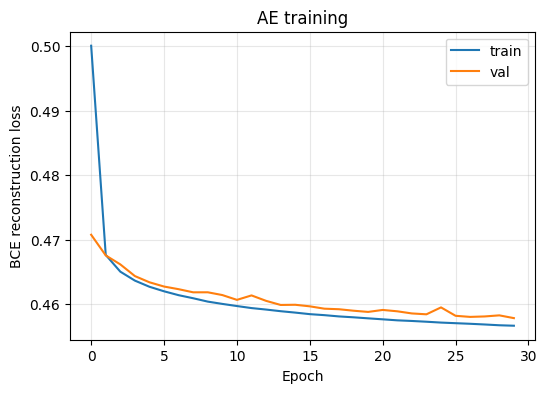

In [24]:
# AE loss curve
plt.figure(figsize=(6, 4))
plt.plot(ae_history.history['loss'], label='train')
plt.plot(ae_history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('BCE reconstruction loss'); plt.title('AE training')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIG_DIR, '02_ae_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Variational Autoencoder (VAE)

The encoder outputs `(z_mean, z_log_var)` and we sample `z = mu + sigma * eps` via the reparameterisation trick. The decoder maps `z` back to an image. Loss = reconstruction (BCE, summed over pixels) + KL divergence between `N(mu, sigma^2)` and `N(0, I)`.

Implemented as a custom `keras.Model` subclass with a `train_step` override (the standard pattern).

In [25]:
class Sampling(layers.Layer):
    """Reparameterisation trick: z = mu + sigma * eps."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        eps = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

def build_vae_encoder():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(32, 3, strides=2, activation='relu', padding='same')(inp)  # 32x32
    x = layers.Conv2D(64, 3, strides=2, activation='relu', padding='same')(x)    # 16x16
    x = layers.Conv2D(64, 3, strides=2, activation='relu', padding='same')(x)    #  8x8
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    z_mean = layers.Dense(LATENT_DIM, name='z_mean')(x)
    z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(inp, [z_mean, z_log_var, z], name='vae_encoder')

def build_vae_decoder():
    inp = keras.Input(shape=(LATENT_DIM,))
    x = layers.Dense(8 * 8 * 64, activation='relu')(inp)
    x = layers.Reshape((8, 8, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)  # 16x16
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)  # 32x32
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)  # 64x64
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    return keras.Model(inp, out, name='vae_decoder')

class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=1.0, **kw):
        super().__init__(**kw)
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight
        self.total_tracker = keras.metrics.Mean(name='loss')
        self.rec_tracker   = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_tracker    = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def call(self, inputs, training=False):
        _, _, z = self.encoder(inputs, training=training)
        return self.decoder(z, training=training)

    def _compute_losses(self, x, x_hat, z_mean, z_log_var):
        # Reconstruction: BCE summed over pixels (standard for VAE)
        bce = keras.losses.binary_crossentropy(x, x_hat)
        rec = tf.reduce_mean(tf.reduce_sum(bce, axis=(1, 2)))
        # KL divergence to N(0, I), summed over latent dims
        kl = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total = rec + self.kl_weight * kl
        return total, rec, kl

    def train_step(self, data):
        x, _ = data if isinstance(data, tuple) else (data, data)
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            x_hat = self.decoder(z, training=True)
            total, rec, kl = self._compute_losses(x, x_hat, z_mean, z_log_var)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_tracker.update_state(total)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, _ = data if isinstance(data, tuple) else (data, data)
        z_mean, z_log_var, z = self.encoder(x, training=False)
        x_hat = self.decoder(z, training=False)
        total, rec, kl = self._compute_losses(x, x_hat, z_mean, z_log_var)
        self.total_tracker.update_state(total)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

vae_encoder = build_vae_encoder()
vae_decoder = build_vae_decoder()
vae = VAE(vae_encoder, vae_decoder, kl_weight=0.25)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
vae_encoder.summary()
vae_decoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │     18,496 │ conv2d_12[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 8, 8, 64)  │     36,928 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4096)      │          0 │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    524,416 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      2,064 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      2,064 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 584,288 (2.23 MB)

 Trainable params: 584,288 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 64, 64, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,561 (525.63 KB)

 Trainable params: 134,561 (525.63 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
vae_history = vae.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
vae_encoder.save(os.path.join(MODEL_DIR, 'vae_encoder.keras'))
vae_decoder.save(os.path.join(MODEL_DIR, 'vae_decoder.keras'))

Epoch 1/30
369/369 - 20s - 53ms/step - kl_loss: 35.6237 - loss: 2168.7756 - reconstruction_loss: 2159.8679 - val_kl_loss: 44.1208 - val_loss: 2015.1069 - val_reconstruction_loss: 2004.0764
Epoch 2/30
369/369 - 10s - 27ms/step - kl_loss: 43.6222 - loss: 1983.2145 - reconstruction_loss: 1972.3086 - val_kl_loss: 43.7770 - val_loss: 1978.4723 - val_reconstruction_loss: 1967.5275
Epoch 3/30
369/369 - 10s - 27ms/step - kl_loss: 43.5138 - loss: 1959.6694 - reconstruction_loss: 1948.7914 - val_kl_loss: 43.1708 - val_loss: 1965.1918 - val_reconstruction_loss: 1954.3994
Epoch 4/30
369/369 - 10s - 28ms/step - kl_loss: 43.3180 - loss: 1948.2590 - reconstruction_loss: 1937.4301 - val_kl_loss: 43.0394 - val_loss: 1954.7229 - val_reconstruction_loss: 1943.9629
Epoch 5/30
369/369 - 10s - 26ms/step - kl_loss: 43.2519 - loss: 1940.0656 - reconstruction_loss: 1929.2532 - val_kl_loss: 43.1576 - val_loss: 1949.9572 - val_reconstruction_loss: 1939.1681
Epoch 6/30
369/369 - 10s - 27ms/step - kl_loss: 43.0935

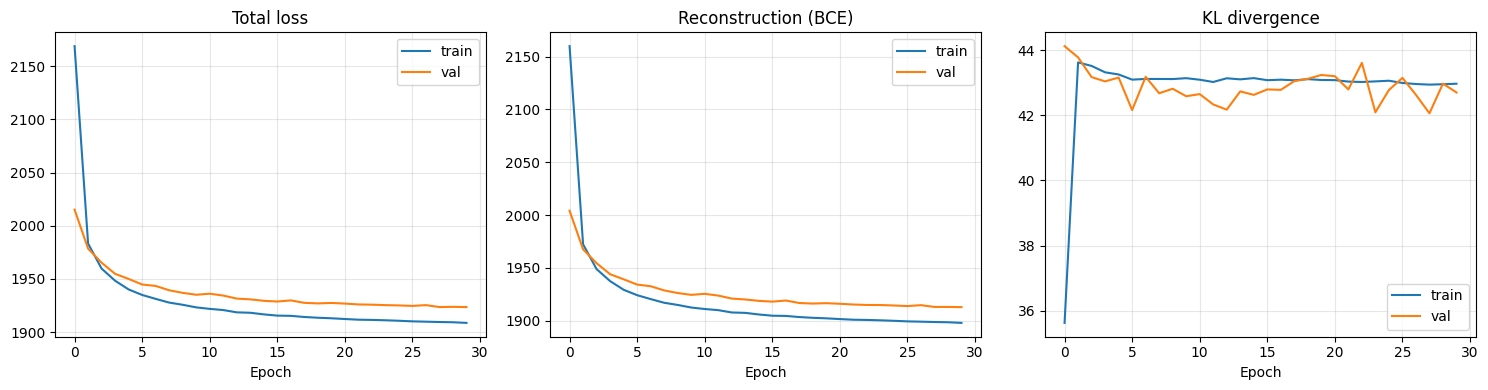

In [27]:
# VAE loss curves: total, reconstruction, KL (training + validation)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(
    axes,
    ['loss', 'reconstruction_loss', 'kl_loss'],
    ['Total loss', 'Reconstruction (BCE)', 'KL divergence'],
):
    ax.plot(vae_history.history[key], label='train')
    val_key = 'val_' + key
    if val_key in vae_history.history:
        ax.plot(vae_history.history[val_key], label='val')
    ax.set_xlabel('Epoch'); ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_vae_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Reconstruction comparison (AE vs VAE)

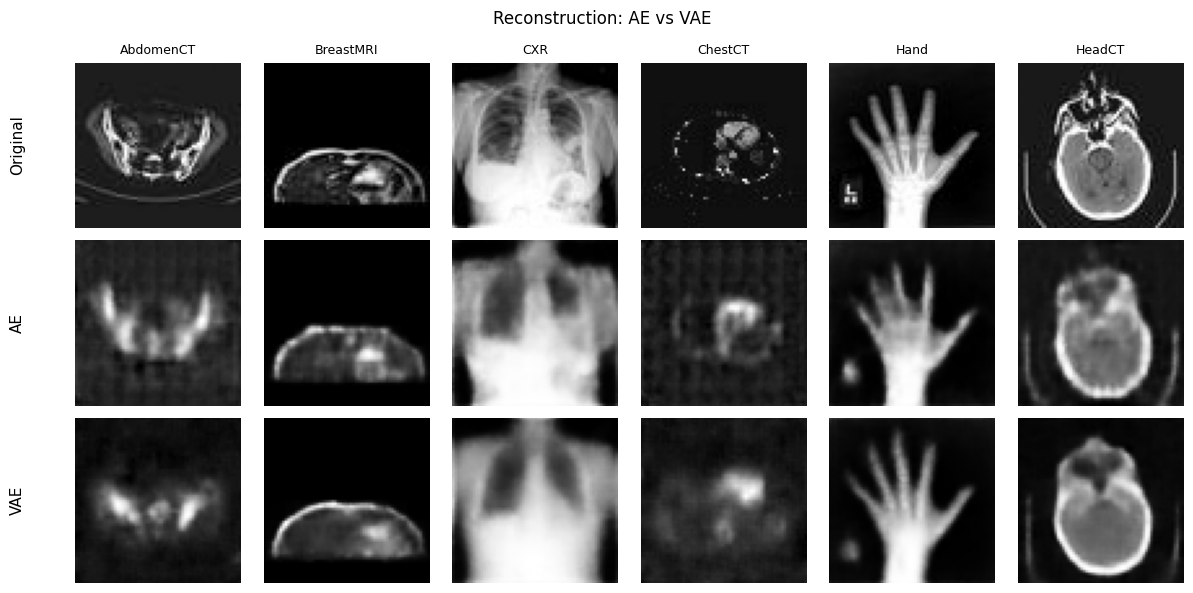

In [28]:
# Grab one batch of labelled test images (one example per class where possible)
x_batch, y_batch = next(iter(test_ds_labelled))
x_batch = x_batch.numpy(); y_batch = y_batch.numpy()
# pick first occurrence of each class
pick_idx = []
for c in range(len(CLASS_NAMES)):
    where = np.where(y_batch == c)[0]
    if len(where): pick_idx.append(where[0])
pick_idx = np.array(pick_idx)
samples = x_batch[pick_idx]
sample_labels = y_batch[pick_idx]

ae_rec  = ae.predict(samples, verbose=0)
vae_rec = vae.predict(samples, verbose=0)

n = len(samples)
fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
for i in range(n):
    axes[0, i].imshow(samples[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[0, i].set_title(CLASS_NAMES[sample_labels[i]], fontsize=9)
    axes[1, i].imshow(ae_rec[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(vae_rec[i].squeeze(), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('AE', fontsize=10)
axes[2, 0].set_ylabel('VAE', fontsize=10)
# re-enable y-labels on the first column
for row, name in enumerate(['Original', 'AE', 'VAE']):
    axes[row, 0].text(-0.35, 0.5, name, rotation=90, fontsize=11,
                      va='center', ha='center', transform=axes[row, 0].transAxes)
plt.suptitle('Reconstruction: AE vs VAE')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_reconstruction_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Quantitative reconstruction metrics on the test set (MSE and pixel-wise MAE)
def compute_recon_metrics(model, ds):
    mses, maes = [], []
    for x, _ in ds:
        x_hat = model(x, training=False)
        mses.append(tf.reduce_mean(tf.square(x - x_hat)).numpy())
        maes.append(tf.reduce_mean(tf.abs(x - x_hat)).numpy())
    return float(np.mean(mses)), float(np.mean(maes))

ae_mse,  ae_mae  = compute_recon_metrics(ae,  test_ds)
vae_mse, vae_mae = compute_recon_metrics(vae, test_ds)

print(f'AE  -> test MSE: {ae_mse:.5f} | test MAE: {ae_mae:.5f}')
print(f'VAE -> test MSE: {vae_mse:.5f} | test MAE: {vae_mae:.5f}')

with open(os.path.join(OUT_DIR, 'metrics.txt'), 'w') as f:
    f.write(f'AE  test MSE: {ae_mse:.6f}\n')
    f.write(f'AE  test MAE: {ae_mae:.6f}\n')
    f.write(f'VAE test MSE: {vae_mse:.6f}\n')
    f.write(f'VAE test MAE: {vae_mae:.6f}\n')

AE  -> test MSE: 0.00429 | test MAE: 0.03546
VAE -> test MSE: 0.00699 | test MAE: 0.04491


## 6. Latent-space visualisation

For the AE, we flatten the 8x8x8 bottleneck feature map and project to 2D with PCA. For the VAE, we project `z_mean` to 2D with PCA (if `LATENT_DIM > 2`) so the two plots are directly comparable.

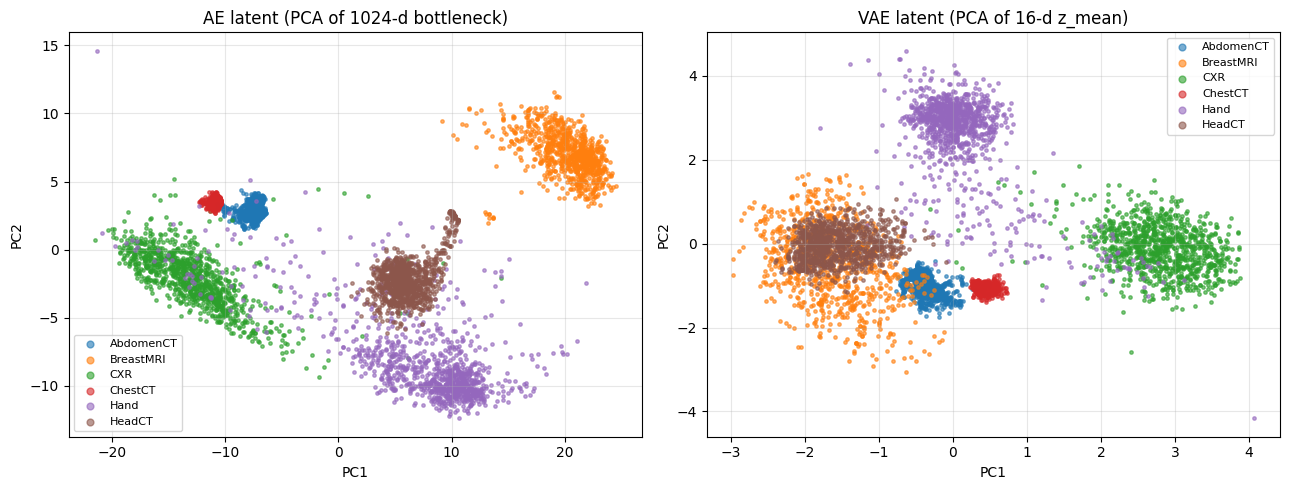

In [30]:
from sklearn.decomposition import PCA

def gather_latents(ds, latent_fn):
    Zs, Ys = [], []
    for x, y in ds:
        z = latent_fn(x)
        Zs.append(z.numpy() if hasattr(z, 'numpy') else z)
        Ys.append(y.numpy())
    return np.concatenate(Zs, 0), np.concatenate(Ys, 0)

# AE latent: spatial feature map -> flatten
ae_latent_fn = lambda x: tf.reshape(ae_encoder(x, training=False), (tf.shape(x)[0], -1))
Z_ae, Y_ae = gather_latents(test_ds_labelled, ae_latent_fn)

# VAE latent: use mean
vae_latent_fn = lambda x: vae_encoder(x, training=False)[0]
Z_vae, Y_vae = gather_latents(test_ds_labelled, vae_latent_fn)

Z_ae_2d  = PCA(n_components=2, random_state=SEED).fit_transform(Z_ae)
Z_vae_2d = PCA(n_components=2, random_state=SEED).fit_transform(Z_vae)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z, Y, title in zip(axes,
                            [Z_ae_2d, Z_vae_2d],
                            [Y_ae, Y_vae],
                            [f'AE latent (PCA of {Z_ae.shape[1]}-d bottleneck)',
                             f'VAE latent (PCA of {LATENT_DIM}-d z_mean)']):
    for c in range(len(CLASS_NAMES)):
        m = Y == c
        ax.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.6, label=CLASS_NAMES[c])
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_latent_space_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Sample generation from the VAE prior

Sample `z ~ N(0, I)` and decode. This is the main capability a VAE has and a plain AE does not.

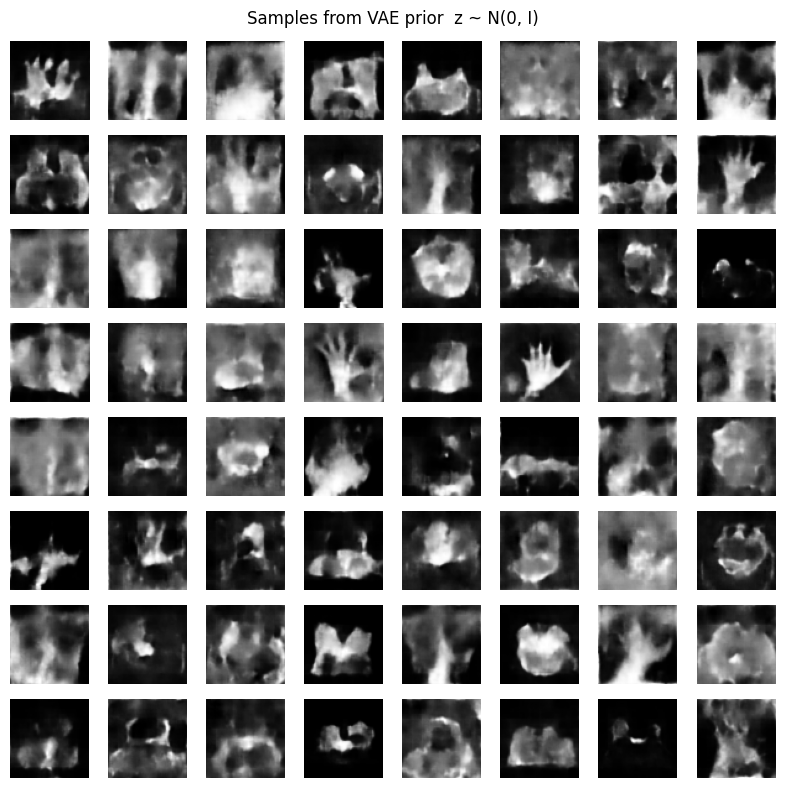

In [31]:
n_samples = 64
z = tf.random.normal(shape=(n_samples, LATENT_DIM))
generated = vae_decoder(z, training=False).numpy()

grid = 8
fig, axes = plt.subplots(grid, grid, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle('Samples from VAE prior  z ~ N(0, I)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_vae_generated_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

# Attempting the same with the plain AE for comparison -- the bottleneck is 8x8x8, random noise there will not look like data
z_ae = tf.random.normal(shape=(n_samples, 8, 8, AE_BOTTLENECK_CHANNELS))
# need decoder-only path for AE -- build it by taking the sub-graph from the encoded tensor:
# Easier: decode random noise directly via the trained autoencoder's decoder layers by
# constructing a second model that shares weights with the AE decoder section.
# The AE was built functionally; the simplest route is to just feed the bottleneck shape through a
# mini-model that reuses the decoder layers. Since we only built it inline, we re-derive by running
# the trained AE on random *images* vs. random latents is not trivial; we skip that here and just
# note in the report that AE cannot meaningfully sample from a prior.

### 7.1 Latent-space interpolation (VAE)

Linearly interpolate between two test-image encodings in latent space and decode each step. Smooth transitions indicate a well-structured latent manifold.

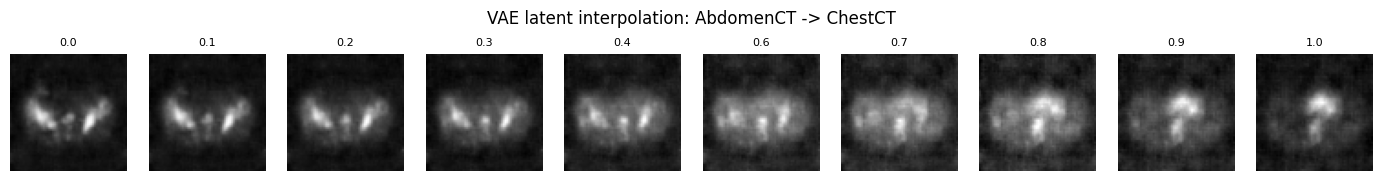

In [32]:
# Pick two images from different classes
idx_a = int(np.where(y_batch == 0)[0][0])
idx_b = int(np.where(y_batch == min(3, len(CLASS_NAMES) - 1))[0][0])
x_a, x_b = x_batch[idx_a:idx_a+1], x_batch[idx_b:idx_b+1]
mu_a, _, _ = vae_encoder(x_a, training=False)
mu_b, _, _ = vae_encoder(x_b, training=False)
mu_a = mu_a.numpy(); mu_b = mu_b.numpy()

n_steps = 10
alphas = np.linspace(0, 1, n_steps)
interp = np.array([(1 - a) * mu_a[0] + a * mu_b[0] for a in alphas])
imgs = vae_decoder(interp, training=False).numpy()

fig, axes = plt.subplots(1, n_steps, figsize=(1.4 * n_steps, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].squeeze(), cmap='gray'); ax.axis('off')
    ax.set_title(f'{alphas[i]:.1f}', fontsize=8)
plt.suptitle(f'VAE latent interpolation: {CLASS_NAMES[y_batch[idx_a]]} -> {CLASS_NAMES[y_batch[idx_b]]}')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_vae_interpolation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Denoising

Add Gaussian noise to test images and feed them *unchanged* (i.e., we do **not** retrain on noisy inputs; this tests natural robustness of the learned representation). Expectation: both AE and VAE will clean noise partly; VAE, because its latent prior is regularised, often smooths more.

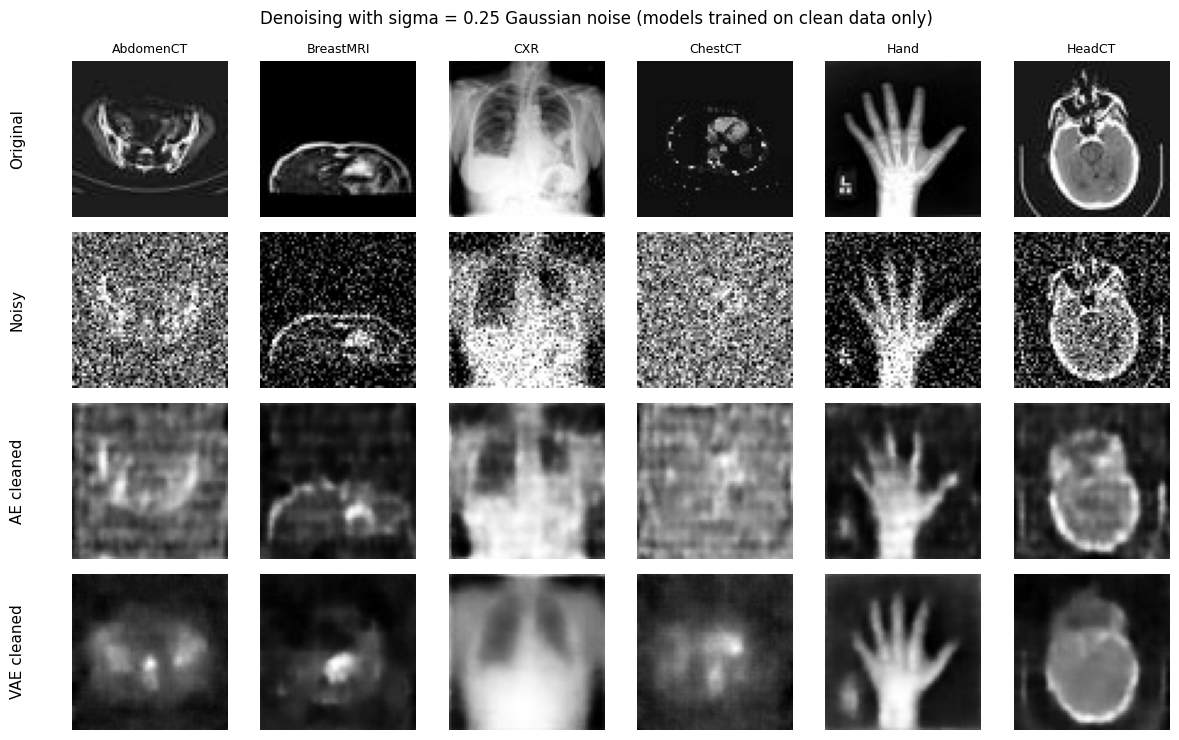

In [33]:
noise_std = 0.25
noisy = np.clip(samples + np.random.normal(0.0, noise_std, samples.shape), 0.0, 1.0).astype(np.float32)
ae_den  = ae.predict(noisy, verbose=0)
vae_den = vae.predict(noisy, verbose=0)

n = len(samples)
fig, axes = plt.subplots(4, n, figsize=(2 * n, 7.5))
rows = [('Original', samples), ('Noisy', noisy), ('AE cleaned', ae_den), ('VAE cleaned', vae_den)]
for r, (name, arr) in enumerate(rows):
    for i in range(n):
        axes[r, i].imshow(arr[i].squeeze(), cmap='gray'); axes[r, i].axis('off')
    axes[r, 0].text(-0.35, 0.5, name, rotation=90, fontsize=11,
                    va='center', ha='center', transform=axes[r, 0].transAxes)
for i in range(n):
    axes[0, i].set_title(CLASS_NAMES[sample_labels[i]], fontsize=9)
plt.suptitle(f'Denoising with sigma = {noise_std} Gaussian noise (models trained on clean data only)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_denoising.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary of saved artifacts

In [34]:
print('Figures saved under:', FIG_DIR)
for f in sorted(os.listdir(FIG_DIR)):
    print(' -', f)
print('\nModels saved under:', MODEL_DIR)
for f in sorted(os.listdir(MODEL_DIR)):
    print(' -', f)
print('\nMetrics file: /kaggle/working/metrics.txt')

Figures saved under: /kaggle/working/figures
 - 01_dataset_samples.png
 - 02_ae_loss.png
 - 03_vae_loss.png
 - 04_reconstruction_comparison.png
 - 05_latent_space_pca.png
 - 06_vae_generated_samples.png
 - 07_vae_interpolation.png
 - 08_denoising.png

Models saved under: /kaggle/working/models
 - ae.keras
 - vae_decoder.keras
 - vae_encoder.keras

Metrics file: /kaggle/working/metrics.txt
